In [5]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df=yf.download("BTC-USD")
print(df.head())
print(df.shape)


/tmp/ipykernel_1610/335611721.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("BTC-USD")
[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2026-04-26  78657.539062  78923.562500  77334.890625  77613.117188   
2026-04-27  77366.625000  79488.171875  76481.343750  78661.015625   
2026-04-28  76350.671875  77483.867188  75673.601562  77368.117188   
2026-04-29  75776.132812  77884.968750  74958.570312  76350.687500   
2026-04-30  76304.320312  76611.484375  75318.984375  75778.632812   

Price            Volume  
Ticker          BTC-USD  
Date                     
2026-04-26  21482934750  
2026-04-27  38135631927  
2026-04-28  32056900880  
2026-04-29  41460907886  
2026-04-30  29497862305  
(31, 5)


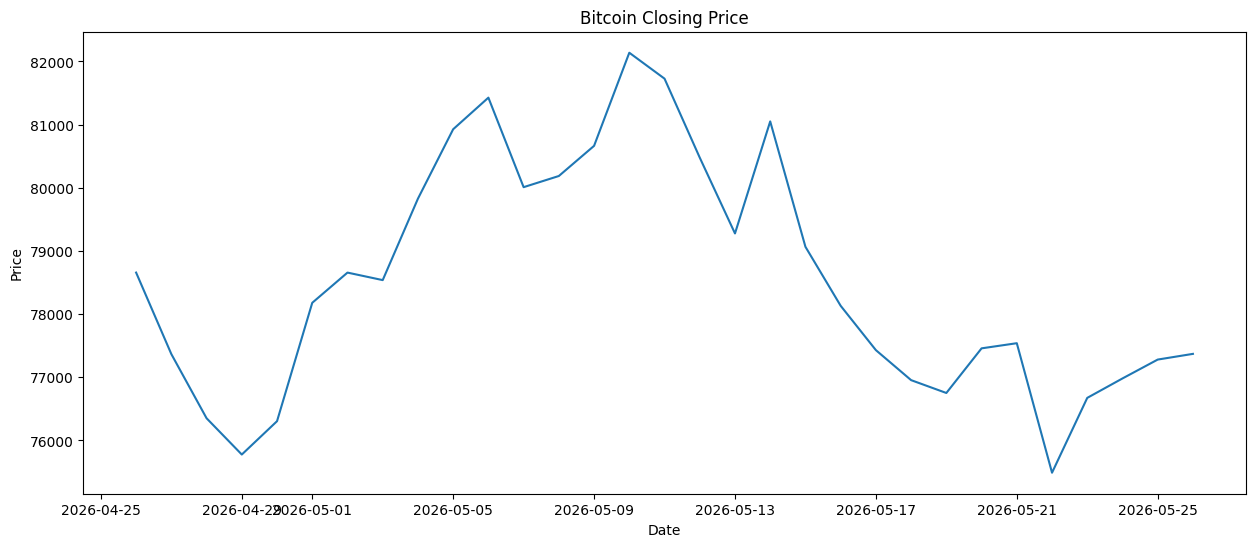

In [6]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"])

plt.title("Bitcoin Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = yf.download("BTC-USD", period="5y")

print(df.head())
print(df.shape)
print(df.columns)

df = df[["Close"]].copy()

df["Prev_Close"] = df["Close"].shift(1)

df = df.dropna()

x = df[["Prev_Close"]]
y = df["Close"]

split_index = int(len(df) * 0.8)

x_train = x.iloc[:split_index]
x_test = x.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(x_train.shape)
print(x_test.shape)

model = LinearRegression()
model.fit(x_train, y_train)

print("Model Trained")

/tmp/ipykernel_1610/3540416740.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", period="5y")
[*********************100%***********************]  1 of 1 completed


Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2021-05-26  39294.199219  40782.078125  37905.835938  38392.625000   
2021-05-27  38436.968750  40379.617188  37247.902344  39316.890625   
2021-05-28  35697.605469  38856.968750  34779.039062  38507.082031   
2021-05-29  34616.066406  37234.500000  33693.929688  35684.156250   
2021-05-30  35678.128906  36400.667969  33520.738281  34607.406250   

Price            Volume  
Ticker          BTC-USD  
Date                     
2021-05-26  51346735160  
2021-05-27  43210968721  
2021-05-28  55200191952  
2021-05-29  45231013335  
2021-05-30  31646080921  
(1827, 5)
MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])
(1460, 

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1415.722250941021
MSE: 3815149.8184539345
RMSE: 1953.2408500883691
R2 Score: 0.9881416897394979


In [20]:
import joblib

joblib.dump(model, "bitcoin_price_model.pkl")

print("Model Saved")

Model Saved
